# Basic
The purpose of this notebook is not to find the best model. I want to verify whether there are task-related signals between the original text representation and the generated reasoning representation; and then test whether adding reasoning or alignment features helps toxic or non-toxic classification.

In [3]:
# install packages used in this notebook
!pip install -q pandas numpy scikit-learn torch transformers tqdm matplotlib

In [4]:
# basic imports
from pathlib import Path
import random

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from google.colab import drive
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel, AutoModelForSeq2SeqLM

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

In [5]:
# experiment settings
seed = 42
sample_per_class = 150
test_size = 0.2

# mount Google Drive
drive.mount('/content/drive')

project_dir = Path('/content/drive/MyDrive/Colab Notebooks/Project')
data_dir = project_dir / 'jigsaw-toxic-comment-classification-challenge'
output_dir = project_dir / 'demo_outputs'
output_dir.mkdir(parents=True, exist_ok=True)

processed_data_path = project_dir / 'processed_data' / 'jigsaw_binary_sample.csv'
reasoning_path = output_dir / 'ablation_reasoning_outputs.csv'

text_encoder_name = 'roberta-base'
reasoning_model_name = 'google/flan-t5-base'

# fix random seeds so the split and sample are repeatable
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)
print('output folder:', output_dir)

Mounted at /content/drive
device: cuda
output folder: /content/drive/MyDrive/Colab Notebooks/Project/demo_outputs


# Alignment

In [6]:
# load Jigsaw data
# convert the six Jigsaw toxicity labels into one binary label
# 1 means toxic / 0 means non-toxic
if processed_data_path.exists():
    jigsaw_df = pd.read_csv(processed_data_path)
    print('loaded processed data:', processed_data_path)
else:
    train_csv_path = data_dir / 'train.csv'
    print('expected train.csv:', train_csv_path)
    print('train.csv exists:', train_csv_path.exists())

    if not train_csv_path.exists():
        raise FileNotFoundError('Cannot find train.csv.')

    raw_df = pd.read_csv(train_csv_path)

    toxic_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
    raw_df['label'] = raw_df[toxic_cols].max(axis=1).astype(int)

    jigsaw_df = raw_df[['comment_text', 'label']].rename(columns={'comment_text': 'text'})
    jigsaw_df['text'] = jigsaw_df['text'].astype(str)
    jigsaw_df = jigsaw_df.dropna(subset=['text', 'label']).reset_index(drop=True)

    processed_data_path.parent.mkdir(parents=True, exist_ok=True)
    jigsaw_df.to_csv(processed_data_path, index=False)
    print('saved processed data:', processed_data_path)

print('full data shape:', jigsaw_df.shape)
print(jigsaw_df['label'].value_counts())

loaded processed data: /content/drive/MyDrive/Colab Notebooks/Project/processed_data/jigsaw_binary_sample.csv
full data shape: (159571, 2)
label
0    143346
1     16225
Name: count, dtype: int64


In [7]:
# use a small balanced sample for this demo
toxic_df = jigsaw_df[jigsaw_df['label'] == 1]
normal_df = jigsaw_df[jigsaw_df['label'] == 0]

toxic_sample = toxic_df.sample(n=sample_per_class, random_state=seed)
normal_sample = normal_df.sample(n=sample_per_class, random_state=seed)

work_df = pd.concat([toxic_sample, normal_sample], axis=0)
work_df = work_df.sample(frac=1, random_state=seed).reset_index(drop=True)

sample_path = output_dir / 'balanced_sample.csv'
work_df.to_csv(sample_path, index=False)

print('sample shape:', work_df.shape)
print(work_df['label'].value_counts())

sample shape: (300, 2)
label
0    150
1    150
Name: count, dtype: int64


In [8]:
# generate reasoning
# use FLAN-T5 to produce a short toxic or non-toxic judgement and a short reason
def make_prompt(text):
    return f"""
Classify the following text as toxic or non-toxic.
Then give one short reason.

Text:
{text}

Answer with:
Label:
Reason:
""".strip()


def generate_reasoning(text, tokenizer, model, max_new_tokens=64):
    prompt = make_prompt(text)
    inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=512).to(device)

    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)

    return tokenizer.decode(output[0], skip_special_tokens=True).strip()


if reasoning_path.exists():
    work_df = pd.read_csv(reasoning_path)
    print('loaded saved reasoning:', reasoning_path)
else:
    reason_tokenizer = AutoTokenizer.from_pretrained(reasoning_model_name)
    reason_model = AutoModelForSeq2SeqLM.from_pretrained(reasoning_model_name).to(device)
    reason_model.eval()

    reason_list = []
    for text in tqdm(work_df['text'].astype(str).tolist()):
        reason_list.append(generate_reasoning(text, reason_tokenizer, reason_model))

    work_df['reasoning'] = reason_list
    work_df.to_csv(reasoning_path, index=False)
    print('saved reasoning:', reasoning_path)

work_df[['text', 'label', 'reasoning']].head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

  0%|          | 0/300 [00:00<?, ?it/s]

saved reasoning: /content/drive/MyDrive/Colab Notebooks/Project/demo_outputs/ablation_reasoning_outputs.csv


,text,label,reasoning
0,"""\n\nNegal/Nergal\nI did provide a citation: ...",0,Non-toxic
1,Says you. That's your opinion only. All of the...,0,Non-toxic
2,SWOT analysis \n\nThis source – Align Technolo...,0,Non-toxic
3,Groin \n\nYou sad fuck. I'm going to restore m...,1,Non-toxic
4,Removed line regarding academic rejection \n\n...,0,Non-toxic


In [9]:
# encode text and reasoning with RoBERTa
# use RoBERTa [CLS] representations for both the original text and the generated reasoning, so they are in the same representation space
text_tokenizer = AutoTokenizer.from_pretrained(text_encoder_name)
text_encoder = AutoModel.from_pretrained(text_encoder_name).to(device)
text_encoder.eval()


def encode_cls(text_list, batch_size=16):
    vecs = []
    for start in tqdm(range(0, len(text_list), batch_size)):
        batch = text_list[start:start + batch_size]
        inputs = text_tokenizer(batch, padding=True, truncation=True, max_length=256, return_tensors='pt').to(device)

        with torch.no_grad():
            output = text_encoder(**inputs)

        # RoBERTa uses the first token representation as a sentence-level vector here
        batch_vec = output.last_hidden_state[:, 0, :].cpu().numpy()
        vecs.append(batch_vec)

    return np.concatenate(vecs, axis=0)

texts = work_df['text'].astype(str).tolist()
reasons = work_df['reasoning'].astype(str).tolist()
labels = work_df['label'].astype(int).values

text_vecs = encode_cls(texts)
reason_vecs = encode_cls(reasons)

print('text_vecs:', text_vecs.shape)
print('reason_vecs:', reason_vecs.shape)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

text_vecs: (300, 768)
reason_vecs: (300, 768)


In [10]:
# build simple alignment features
# these are only simple features that describe the relationship between h_text and h_reason
# global similarity
cos_list = []
for i in range(len(text_vecs)):
    score = cosine_similarity(text_vecs[i].reshape(1, -1), reason_vecs[i].reshape(1, -1))[0][0]
    cos_list.append(score)
cos_scores = np.array(cos_list).reshape(-1, 1)

# dimension-level distance
abs_diff = np.abs(text_vecs - reason_vecs)

# dimension-level interaction
elem_product = text_vecs * reason_vecs

print('cos_scores:', cos_scores.shape)
print('abs_diff:', abs_diff.shape)
print('elem_product:', elem_product.shape)

cos_scores: (300, 1)
abs_diff: (300, 768)
elem_product: (300, 768)


Alignment features grouped by label:


cosine           mean_abs_diff           mean_product          
           mean       std          mean       std         mean       std
label                                                                   
0      0.995919  0.001317      0.028475  0.005323     0.160773  0.004088
1      0.995393  0.002036      0.030339  0.008029     0.162973  0.006095

saved: /content/drive/MyDrive/Colab Notebooks/Project/demo_outputs/alignment_signal_by_label.csv


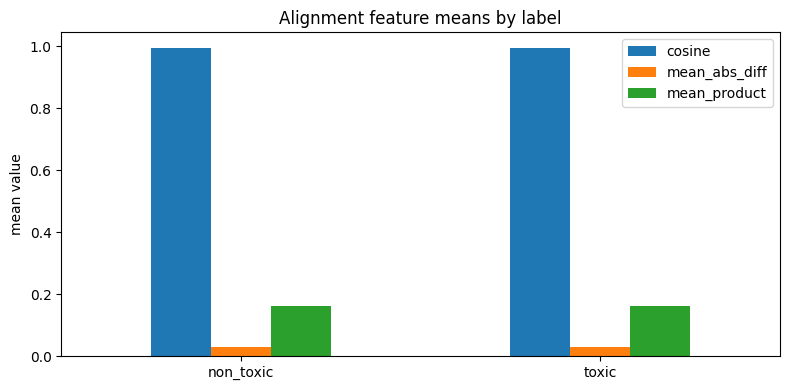

saved chart: /content/drive/MyDrive/Colab Notebooks/Project/demo_outputs/alignment_features_by_label.png


In [11]:
# alignment signal analysis
# check whether these text-reasoning relationship features have any task-related pattern
align_df = work_df.copy()
align_df['cosine'] = cos_scores.flatten()
align_df['mean_abs_diff'] = abs_diff.mean(axis=1)
align_df['mean_product'] = elem_product.mean(axis=1)

label_summary = align_df.groupby('label')[['cosine', 'mean_abs_diff', 'mean_product']].agg(['mean', 'std'])
print('Alignment features grouped by label:')
display(label_summary)

align_summary_path = output_dir / 'alignment_signal_by_label.csv'
label_summary.to_csv(align_summary_path)
print('saved:', align_summary_path)

# simple chart for the label-level alignment signal
label_mean = align_df.groupby('label')[['cosine', 'mean_abs_diff', 'mean_product']].mean()
label_mean.index = ['non_toxic', 'toxic']

plt.figure(figsize=(8, 4))
label_mean.plot(kind='bar', ax=plt.gca())
plt.title('Alignment feature means by label')
plt.ylabel('mean value')
plt.xticks(rotation=0)
plt.tight_layout()

chart_path = output_dir / 'alignment_features_by_label.png'
plt.savefig(chart_path, dpi=200)
plt.show()
print('saved chart:', chart_path)

# Ablation

In [12]:
# prepare feature sets for ablation
# compare different feature settings
feature_names = []
feature_mats = []
feature_notes = []

feature_names.append('text_only')
feature_mats.append(text_vecs)
feature_notes.append('only original text representation')

feature_names.append('reasoning_only')
feature_mats.append(reason_vecs)
feature_notes.append('only generated reasoning representation')

feature_names.append('text_reasoning_concat')
feature_mats.append(np.concatenate([text_vecs, reason_vecs], axis=1))
feature_notes.append('text representation + reasoning representation')

feature_names.append('full_alignment')
feature_mats.append(np.concatenate([text_vecs, reason_vecs, cos_scores, abs_diff, elem_product], axis=1))
feature_notes.append('text + reasoning + cosine + abs diff + product')

feature_names.append('without_cosine')
feature_mats.append(np.concatenate([text_vecs, reason_vecs, abs_diff, elem_product], axis=1))
feature_notes.append('full alignment without cosine')

feature_names.append('without_abs_diff')
feature_mats.append(np.concatenate([text_vecs, reason_vecs, cos_scores, elem_product], axis=1))
feature_notes.append('full alignment without abs diff')

feature_names.append('without_product')
feature_mats.append(np.concatenate([text_vecs, reason_vecs, cos_scores, abs_diff], axis=1))
feature_notes.append('full alignment without element-wise product')

for name, mat in zip(feature_names, feature_mats):
    print(name, mat.shape)

text_only (300, 768)
reasoning_only (300, 768)
text_reasoning_concat (300, 1536)
full_alignment (300, 3073)
without_cosine (300, 3072)
without_abs_diff (300, 2305)
without_product (300, 2305)


In [13]:
# one shared split for all ablation settings
all_ids = np.arange(len(labels))
train_ids, test_ids = train_test_split(all_ids, test_size=test_size, random_state=seed, stratify=labels)

print('train size:', len(train_ids))
print('test size:', len(test_ids))

train size: 240
test size: 60


In [14]:
def get_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'false_positive_rate': fp / (fp + tn) if (fp + tn) > 0 else 0,
        'false_negative_rate': fn / (fn + tp) if (fn + tp) > 0 else 0,
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
    }

In [15]:
# run all ablation settings
rows = []
prediction_tables = []

for name, X, note in zip(feature_names, feature_mats, feature_notes):
    X_train = X[train_ids]
    X_test = X[test_ids]
    y_train = labels[train_ids]
    y_test = labels[test_ids]

    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=5000, class_weight='balanced', random_state=seed)),
    ])

    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    metrics = get_metrics(y_test, preds)

    row = {
        'variant': name,
        'note': note,
        'feature_dim': X.shape[1],
        'train_size': len(train_ids),
        'test_size': len(test_ids),
    }
    row.update(metrics)
    rows.append(row)

    pred_df = work_df.iloc[test_ids].copy()
    pred_df['variant'] = name
    pred_df['prediction'] = preds
    pred_df['is_correct'] = pred_df['label'].astype(int).values == preds
    prediction_tables.append(pred_df)

result_df = pd.DataFrame(rows).sort_values(['f1', 'accuracy'], ascending=False).reset_index(drop=True)
all_pred_df = pd.concat(prediction_tables, axis=0).reset_index(drop=True)

result_path = output_dir / 'ablation_results.csv'
pred_path = output_dir / 'ablation_predictions.csv'
result_df.to_csv(result_path, index=False)
all_pred_df.to_csv(pred_path, index=False)

print('saved results:', result_path)
print('saved predictions:', pred_path)

display_cols = ['variant', 'accuracy', 'precision', 'recall', 'f1', 'false_positive_rate', 'false_negative_rate', 'tn', 'fp', 'fn', 'tp']
display(result_df[display_cols])

saved results: /content/drive/MyDrive/Colab Notebooks/Project/demo_outputs/ablation_results.csv
saved predictions: /content/drive/MyDrive/Colab Notebooks/Project/demo_outputs/ablation_predictions.csv


,variant,accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tn,fp,fn,tp
0,text_reasoning_concat,0.866667,0.923077,0.800000,0.857143,0.066667,0.200000,28,2,6,24
1,full_alignment,0.866667,0.923077,0.800000,0.857143,0.066667,0.200000,28,2,6,24
2,without_cosine,0.866667,0.923077,0.800000,0.857143,0.066667,0.200000,28,2,6,24
3,without_product,0.866667,0.923077,0.800000,0.857143,0.066667,0.200000,28,2,6,24
4,text_only,0.850000,0.888889,0.800000,0.842105,0.100000,0.200000,27,3,6,24
5,without_abs_diff,0.850000,0.888889,0.800000,0.842105,0.100000,0.200000,27,3,6,24
6,reasoning_only,0.516667,1.000000,0.033333,0.064516,0.000000,0.966667,30,0,29,1


# Charts

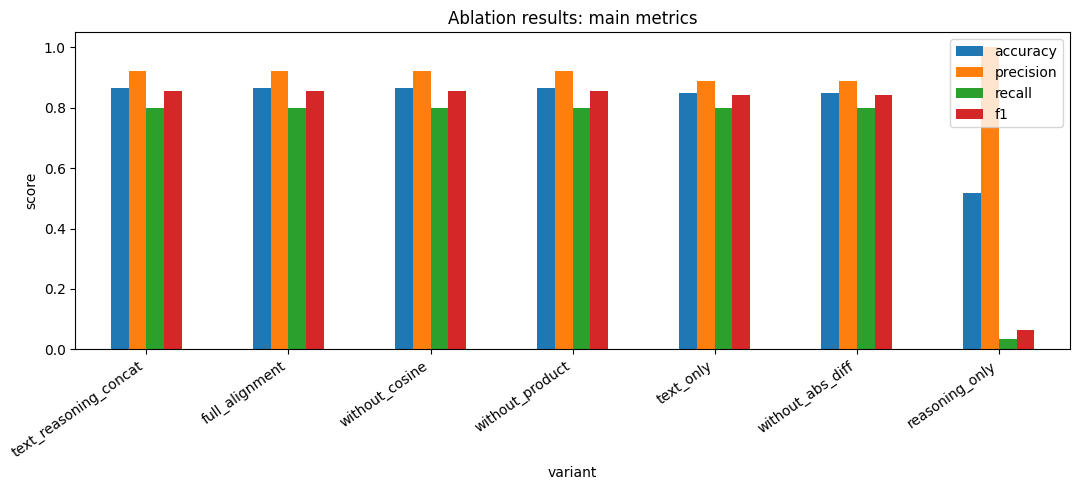

saved chart: /content/drive/MyDrive/Colab Notebooks/Project/demo_outputs/ablation_main_metrics.png


In [16]:
# plot main metrics
plot_df = result_df.set_index('variant')
main_metrics = plot_df[['accuracy', 'precision', 'recall', 'f1']]

plt.figure(figsize=(11, 5))
main_metrics.plot(kind='bar', ax=plt.gca())
plt.title('Ablation results: main metrics')
plt.ylabel('score')
plt.ylim(0, 1.05)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()

main_chart_path = output_dir / 'ablation_main_metrics.png'
plt.savefig(main_chart_path, dpi=200)
plt.show()
print('saved chart:', main_chart_path)

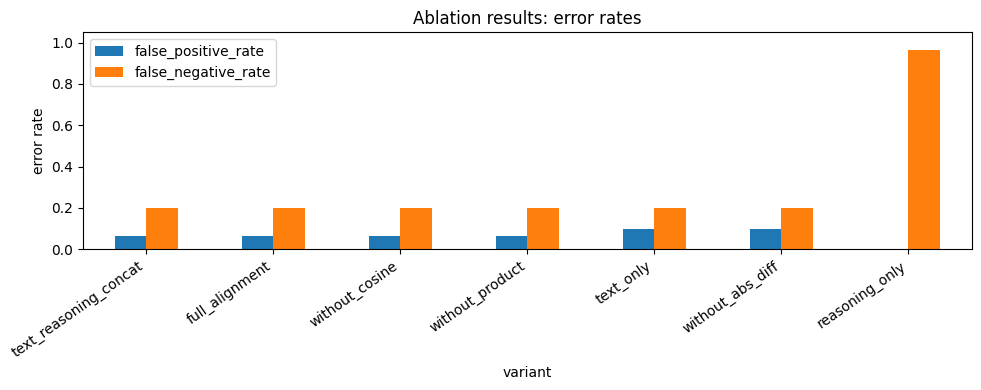

saved chart: /content/drive/MyDrive/Colab Notebooks/Project/demo_outputs/ablation_error_rates.png


In [17]:
# plot error rates
error_metrics = plot_df[['false_positive_rate', 'false_negative_rate']]

plt.figure(figsize=(10, 4))
error_metrics.plot(kind='bar', ax=plt.gca())
plt.title('Ablation results: error rates')
plt.ylabel('error rate')
plt.ylim(0, 1.05)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()

error_chart_path = output_dir / 'ablation_error_rates.png'
plt.savefig(error_chart_path, dpi=200)
plt.show()
print('saved chart:', error_chart_path)

# Supplementary


In [18]:
# check alignment and prediction errors
# help to see whether the relationship between text and reasoning is connected to model errors
# add alignment features to the full_alignment test predictions
full_pred = all_pred_df[all_pred_df['variant'] == 'full_alignment'].copy()
full_pred['cosine'] = cos_scores[test_ids].flatten()
full_pred['mean_abs_diff'] = abs_diff[test_ids].mean(axis=1)
full_pred['mean_product'] = elem_product[test_ids].mean(axis=1)

correct_summary = full_pred.groupby('is_correct')[['cosine', 'mean_abs_diff', 'mean_product']].agg(['mean', 'std'])
print('Alignment features grouped by whether full_alignment prediction is correct:')
display(correct_summary)

correct_summary_path = output_dir / 'alignment_signal_by_correctness.csv'
correct_summary.to_csv(correct_summary_path)
print('saved:', correct_summary_path)

# cases where the richer setting fixes text-only mistakes
text_pred = all_pred_df[all_pred_df['variant'] == 'text_only'][['text', 'label', 'prediction']]
text_pred = text_pred.rename(columns={'prediction': 'text_only_pred'})

full_pred_simple = all_pred_df[all_pred_df['variant'] == 'full_alignment'][['text', 'label', 'reasoning', 'prediction']]
full_pred_simple = full_pred_simple.rename(columns={'prediction': 'full_alignment_pred'})

case_df = text_pred.merge(full_pred_simple, on=['text', 'label'], how='inner')

fixed_cases = case_df[(case_df['text_only_pred'] != case_df['label']) & (case_df['full_alignment_pred'] == case_df['label'])]
new_errors = case_df[(case_df['text_only_pred'] == case_df['label']) & (case_df['full_alignment_pred'] != case_df['label'])]

fixed_path = output_dir / 'cases_fixed_by_full_alignment.csv'
new_error_path = output_dir / 'new_errors_from_full_alignment.csv'
fixed_cases.to_csv(fixed_path, index=False)
new_errors.to_csv(new_error_path, index=False)

print('fixed cases:', len(fixed_cases))
print('new errors:', len(new_errors))
print('saved:', fixed_path)
print('saved:', new_error_path)

display(fixed_cases[['text', 'label', 'text_only_pred', 'full_alignment_pred', 'reasoning']].head(10))

Alignment features grouped by whether full_alignment prediction is correct:


cosine           mean_abs_diff           mean_product          
                mean       std          mean       std         mean       std
is_correct                                                                   
False       0.995134  0.000892      0.031769  0.003687     0.163349  0.003932
True        0.995592  0.001694      0.029942  0.007031     0.162926  0.005928

saved: /content/drive/MyDrive/Colab Notebooks/Project/demo_outputs/alignment_signal_by_correctness.csv
fixed cases: 3
new errors: 2
saved: /content/drive/MyDrive/Colab Notebooks/Project/demo_outputs/cases_fixed_by_full_alignment.csv
saved: /content/drive/MyDrive/Colab Notebooks/Project/demo_outputs/new_errors_from_full_alignment.csv


,text,label,text_only_pred,full_alignment_pred,reasoning
19,Congratulations! \n\nYour furious defense of t...,1,0,1,Non-toxic
21,"""\n\nSorry, Paperpencils. I must have miss-jud...",0,1,0,Non-toxic
35,How about you shut up then!!!,1,0,1,Non-toxic


In [19]:
#  record the result in plain language
lookup = result_df.set_index('variant')
text_f1 = lookup.loc['text_only', 'f1']
concat_f1 = lookup.loc['text_reasoning_concat', 'f1']
full_f1 = lookup.loc['full_alignment', 'f1']
no_cos_f1 = lookup.loc['without_cosine', 'f1']

print('My quick notes:')

if concat_f1 > text_f1:
    print('- Adding generated reasoning improves over text-only in this run.')
else:
    print('- Adding generated reasoning does not improve over text-only in this run.')

if full_f1 > concat_f1:
    print('- Full alignment improves over simple text + reasoning concatenation.')
else:
    print('- Full alignment does not improve over simple text + reasoning concatenation yet.')

if full_f1 > no_cos_f1:
    print('- Cosine seems useful in this run.')
else:
    print('- Cosine does not show a clear positive contribution in this run.')

My quick notes:
- Adding generated reasoning improves over text-only in this run.
- Full alignment does not improve over simple text + reasoning concatenation yet.
- Cosine does not show a clear positive contribution in this run.
